# SVD (Singular Value Decomposition)


(100, 60) (60, 60) (60, 60)
====


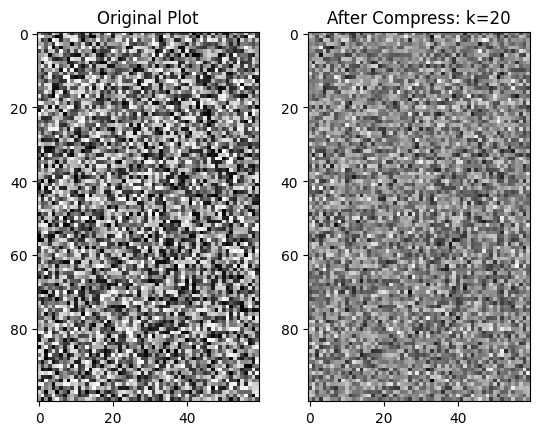

完全SVD维度：
[[-0.08793803 -0.03496927 -0.13107232 ... -0.05245154 -0.00777073
   0.04906516]
 [-0.10598898  0.01229177  0.02282536 ...  0.08126097 -0.01908696
   0.02508989]
 [-0.11386262  0.0201767   0.04913101 ... -0.01965739  0.06768555
  -0.14881358]
 ...
 [-0.09774408 -0.05759778  0.01350983 ... -0.04397538 -0.12342096
  -0.10462138]
 [-0.10581484  0.17725985 -0.01915513 ... -0.0575693   0.04578453
   0.11290459]
 [-0.09617092 -0.07299127  0.06761067 ...  0.11721165 -0.11840922
  -0.10454375]]
U_full: (100, 60)
Σ对角矩阵的奇异值数组: [39.04760491  4.74217653  4.67867098  4.45590884  4.42163345  4.38851603
  4.28583636  4.19245762  4.1286913   4.01275148  3.88894248  3.79971925
  3.69055458  3.63343503  3.59389934  3.52825505  3.44161435  3.35549163
  3.29176234  3.24746516  3.24441491  3.13497987  3.07732471  2.96927469
  2.90663992  2.84443849  2.7950871   2.73767357  2.68350859  2.58375208
  2.56520423  2.50349413  2.40910042  2.37581887  2.26590422  2.22095053
  2.17008242  2.13065044  1.99

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def sortByEigenValue(Eigenvalues, EigenVectors):
    """根据特征值大小重新排序
    """
    index = np.argsort(Eigenvalues)[::-1]
    # 获得降序的索引列表
    Eigenvalues = Eigenvalues[index]
    # 按照降序对特征值进行排列
    EigenVectors = EigenVectors[:, index]
    # 按照降序对特征向量进行排列
    return Eigenvalues, EigenVectors

def SVD(matrixA, truncateNum = None):
    """向量化修正后的手撕SVD
    """
    # matrixA: m * n (m > n)
    # 计算 A^T A 的特征值和特征向量
    AT_mul_A = matrixA.T @ matrixA
    lambda_V, X_V = np.linalg.eig(AT_mul_A)
    # lambda_V: n * 1, X_V: n * n
    lambda_V, X_V = sortByEigenValue(lambda_V, X_V)
    
    # 计算奇异值
    sigmas = np.sqrt(np.maximum(lambda_V, 0))  
    non_zero_mask = sigmas > 1e-10  
    # 数值稳定性处理
    sigmas = sigmas[non_zero_mask]
    # 将特征值截断到为正数的部分
    X_V = X_V[:, non_zero_mask]
    # 将特征向量截断到为正数的部分
    
    # 确定截断的秩 k
    k = truncateNum if truncateNum is not None else len(sigmas)
    k = min(k, len(sigmas))
    sigmas = sigmas[:k]
    X_V = X_V[:, :k]
    # X_V: n * k, 其中 k 为非负特征值的个数
    # 进一步截断特征向量与特征值（如果用户指定truncateNum的话）
    
    
    U = matrixA @ X_V / sigmas.reshape(1, -1)  # 广播除法
    # U = (m * n) @ (n * k) = m * k, 后续的除法相当于对每一列除以开方后的特征值

    Sigma = np.diag(sigmas)
    
    return U, Sigma, X_V.T  # X_V.T 即为 V^T

if __name__ == "__main__":
    image = np.random.rand(100, 60)  # 替换为实际图像数据
    U, sigma, V_T = SVD(image)
    print(U.shape, sigma.shape, V_T.shape)

    print("====")
    # 加载图像（假设为灰度图像矩阵）
    
    
    # 进行SVD分解
    U, S, Vt = np.linalg.svd(image, full_matrices=False)
    
    # 截断前k个奇异值
    k = 20
    compressed_image = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    
    # 显示压缩前后的图像
    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Plot')
    plt.subplot(1,2,2)
    plt.imshow(compressed_image, cmap='gray')
    plt.title(f'After Compress: k={k}')
    plt.show()
    # 示例矩阵：3x2，秩为2
    A = np.array([[1, 1, 1, 2, 2], [0, 0, 0, 3, 3], [0, 0, 0, 1, 1], [1, 1, 1, 0, 0],
                  [2, 2, 2, 0, 0], [5, 5, 5, 0, 0], [1, 1, 1, 0, 0]])
    
    
    # 完全SVD
    U_full, S_full, Vt_full = np.linalg.svd(image, full_matrices=False)
    print("完全SVD维度：")
    print(U_full)
    print("U_full:", U_full.shape)  # (3,3)
    print("Σ对角矩阵的奇异值数组:", S_full)  # 长度2（因为p=min(3,2)=2）
    print("Vt_full:", Vt_full.shape)  # (2,2)
    
    # # 紧SVD（full_matrices=False）
    # U_compact, S_compact, Vt_compact = np.linalg.svd(A, full_matrices=False)
    # print("\n紧SVD维度：")
    # print("U_compact:", U_compact.shape)  # (3,2)
    # print("Σ对角矩阵的奇异值数组:", S_compact)  # 长度2
    # print("Vt_compact:", Vt_compact.shape)  # (2,2)
    
    # # 截断SVD（取k=1）
    # k = 1
    # U_truncated = U_compact[:, :k]
    # S_truncated = S_compact[:k]
    # Vt_truncated = Vt_compact[:k, :]
    # print("\n截断SVD维度：")
    # print("U_truncated:", U_truncated.shape)  # (3,1)
    # print("Σ_truncated:", S_truncated.shape)  # (1,)
    # print("Vt_truncated:", Vt_truncated.shape)  # (1,2)